# 04 — Monte Carlo Comparison: Naive Regression versus IPW

**Goal.** This notebook compares causal estimators over many simulated datasets.

We compare:

1. **Naive regression:** `Y ~ A`;
2. **Adjusted regression:** `Y ~ A + X`;
3. **IPW with estimated propensity score.**

The true average treatment effect is known, which allows us to compute bias and RMSE.

## Why this notebook is useful for a PhD application

It demonstrates:

- simulation-based evaluation;
- causal estimands;
- confounding bias;
- propensity-score weighting;
- positivity problems;
- reproducible computational research.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression, LogisticRegression

FIG_DIR = Path("figures")
RES_DIR = Path("results")
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def summarize_estimates(estimates, true_ate):
    return pd.DataFrame([
        {
            "Estimator": name,
            "Estimate": value,
            "True ATE": true_ate,
            "Bias": value - true_ate,
            "Absolute error": abs(value - true_ate),
        }
        for name, value in estimates.items()
    ])

## 1. Define the simulation and estimation functions

In [9]:
def simulate_data(n=1000, tau=2.0, beta0=1.0, gamma=1.5,
                  treatment_intercept=-0.2, treatment_slope=1.3,
                  noise_sd=1.0, seed=42):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, n)
    p_treat = sigmoid(treatment_intercept + treatment_slope * X)
    A = rng.binomial(1, p_treat, n)
    eps = rng.normal(0, noise_sd, n)
    Y = beta0 + tau * A + gamma * X + eps
    return pd.DataFrame({"X": X, "A": A, "Y": Y, "true_propensity": p_treat})

def estimate_propensity(df):
    model = LogisticRegression(solver="lbfgs")
    model.fit(df[["X"]], df["A"])
    return model.predict_proba(df[["X"]])[:, 1]

def naive_regression_ate(df):
    return LinearRegression().fit(df[["A"]], df["Y"]).coef_[0]

def adjusted_regression_ate(df):
    return LinearRegression().fit(df[["A", "X"]], df["Y"]).coef_[0]

def ipw_hajek_ate(df):
    e = np.clip(estimate_propensity(df), 1e-6, 1 - 1e-6)
    A = df["A"].to_numpy()
    Y = df["Y"].to_numpy()
    mu1 = np.sum(A * Y / e) / np.sum(A / e)
    mu0 = np.sum((1 - A) * Y / (1 - e)) / np.sum((1 - A) / (1 - e))
    return mu1 - mu0

def one_simulation(seed, n=1000, tau=2.0, gamma=1.5, treatment_slope=1.3):
    df = simulate_data(n=n, tau=tau, gamma=gamma, treatment_slope=treatment_slope, seed=seed)
    return {
        "Naive regression Y~A": naive_regression_ate(df),
        "Adjusted regression Y~A+X": adjusted_regression_ate(df),
        "IPW Hajek": ipw_hajek_ate(df),
    }

## 2. Define scenarios

We use three scenarios:

1. **No confounding**: treatment is independent of `X`;
2. **Moderate confounding with overlap**;
3. **Strong confounding / poor positivity**.

In [10]:
TRUE_ATE = 2.0
scenarios = {
    "No confounding": {"gamma": 1.5, "treatment_slope": 0.0},
    "Moderate confounding": {"gamma": 1.5, "treatment_slope": 1.3},
    "Poor positivity": {"gamma": 1.5, "treatment_slope": 4.0},
}
scenarios

{'No confounding': {'gamma': 1.5, 'treatment_slope': 0.0},
 'Moderate confounding': {'gamma': 1.5, 'treatment_slope': 1.3},
 'Poor positivity': {'gamma': 1.5, 'treatment_slope': 4.0}}

## 3. Run Monte Carlo simulations

In [11]:
N_REPLICATIONS = 300
SAMPLE_SIZE = 1000
records = []

for scenario_name, params in scenarios.items():
    for r in range(N_REPLICATIONS):
        estimates = one_simulation(seed=1000 + r, n=SAMPLE_SIZE, tau=TRUE_ATE,
                                   gamma=params["gamma"], treatment_slope=params["treatment_slope"])
        for method, estimate in estimates.items():
            records.append({
                "Scenario": scenario_name,
                "Replication": r,
                "Method": method,
                "Estimate": estimate,
                "True ATE": TRUE_ATE,
                "Error": estimate - TRUE_ATE,
                "Squared error": (estimate - TRUE_ATE) ** 2,
            })

results = pd.DataFrame(records)
results.to_csv(RES_DIR / "04_monte_carlo_results.csv", index=False)
results.head()

,Scenario,Replication,Method,Estimate,True ATE,Error,Squared error
0,No confounding,0,Naive regression Y~A,1.878146,2.0,-0.121854,0.014848
1,No confounding,0,Adjusted regression Y~A+X,1.984717,2.0,-0.015283,0.000234
2,No confounding,0,IPW Hajek,1.986048,2.0,-0.013952,0.000195
3,No confounding,1,Naive regression Y~A,2.054893,2.0,0.054893,0.003013
4,No confounding,1,Adjusted regression Y~A+X,1.986546,2.0,-0.013454,0.000181


## 4. Summary table

Bias and RMSE are computed across replications.

$$
Bias = \mathbb{E}[\hat\tau] - \tau,
\quad
RMSE = \sqrt{\mathbb{E}[(\hat\tau - \tau)^2]}.
$$

In [13]:
summary = (
    results.groupby(["Scenario", "Method"])
    .agg(
        Mean_estimate=("Estimate", "mean"),
        Bias=("Error", "mean"),
        Std=("Estimate", "std"),
        RMSE=("Squared error", lambda x: np.sqrt(np.mean(x))),
    )
    .reset_index()
)
summary.to_csv(RES_DIR / "04_monte_carlo_summary.csv", index=False)
summary

,Scenario,Method,Mean_estimate,Bias,Std,RMSE
0,Moderate confounding,Adjusted regression Y~A+X,1.997664,-0.002336,0.067106,0.067035
1,Moderate confounding,IPW Hajek,2.019812,0.019812,0.130433,0.131714
2,Moderate confounding,Naive regression Y~A,3.462968,1.462968,0.097622,1.466211
3,No confounding,Adjusted regression Y~A+X,1.995764,-0.004236,0.067708,0.067727
4,No confounding,IPW Hajek,1.995723,-0.004277,0.067721,0.067743
5,No confounding,Naive regression Y~A,2.000856,0.000856,0.117931,0.117737
6,Poor positivity,Adjusted regression Y~A+X,1.991043,-0.008957,0.094345,0.094613
7,Poor positivity,IPW Hajek,2.508838,0.508838,0.515471,0.723700
8,Poor positivity,Naive regression Y~A,4.181678,2.181678,0.087195,2.183414


## 5. Visual comparison of estimator distributions

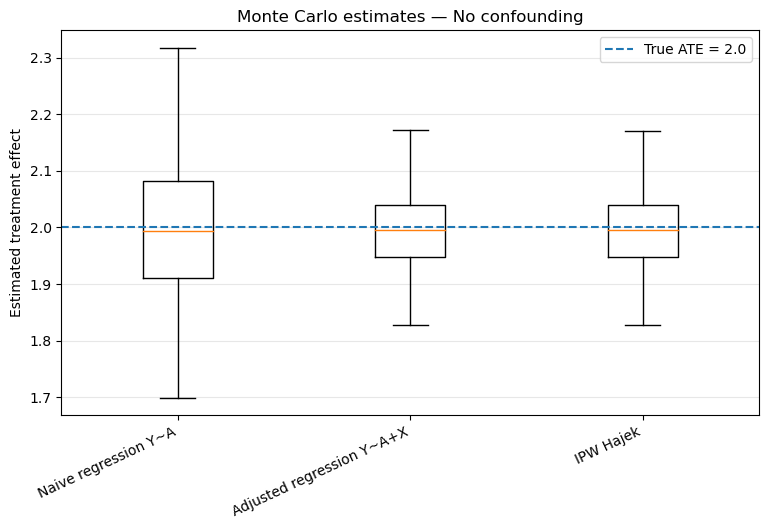

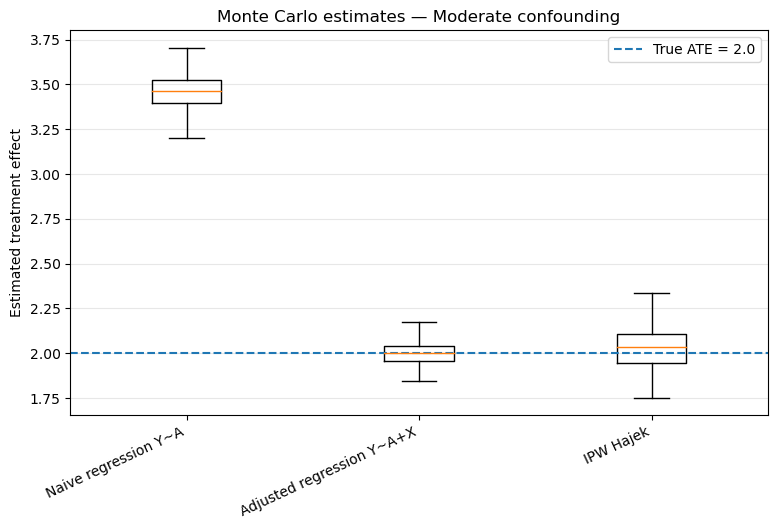

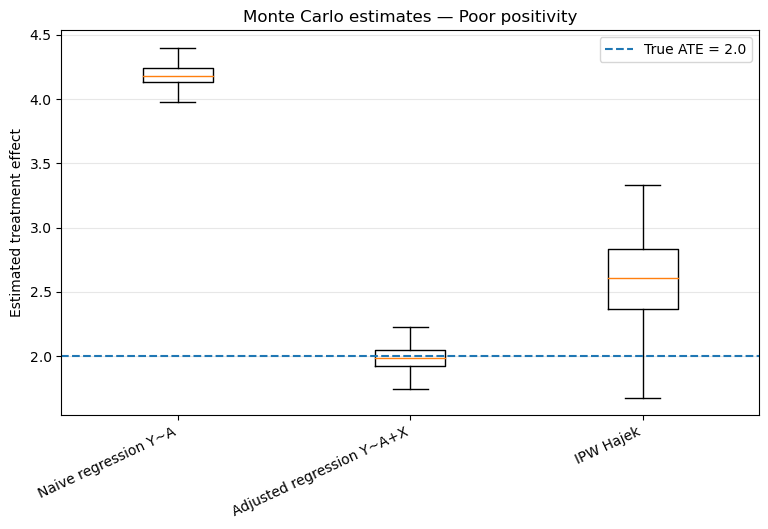

In [14]:
for scenario_name in scenarios.keys():
    subset = results[results["Scenario"] == scenario_name]
    methods = subset["Method"].unique()
    data_to_plot = [subset.loc[subset["Method"] == method, "Estimate"] for method in methods]
    plt.figure(figsize=(9, 5))
    plt.boxplot(data_to_plot, labels=methods, showfliers=False)
    plt.axhline(TRUE_ATE, linestyle="--", label=f"True ATE = {TRUE_ATE}")
    plt.ylabel("Estimated treatment effect")
    plt.title(f"Monte Carlo estimates — {scenario_name}")
    plt.xticks(rotation=25, ha="right")
    plt.legend()
    plt.grid(True, axis="y", alpha=0.3)
    safe_name = scenario_name.lower().replace(" ", "_").replace("/", "_")
    plt.savefig(FIG_DIR / f"04_boxplot_{safe_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

## 6. Bias comparison

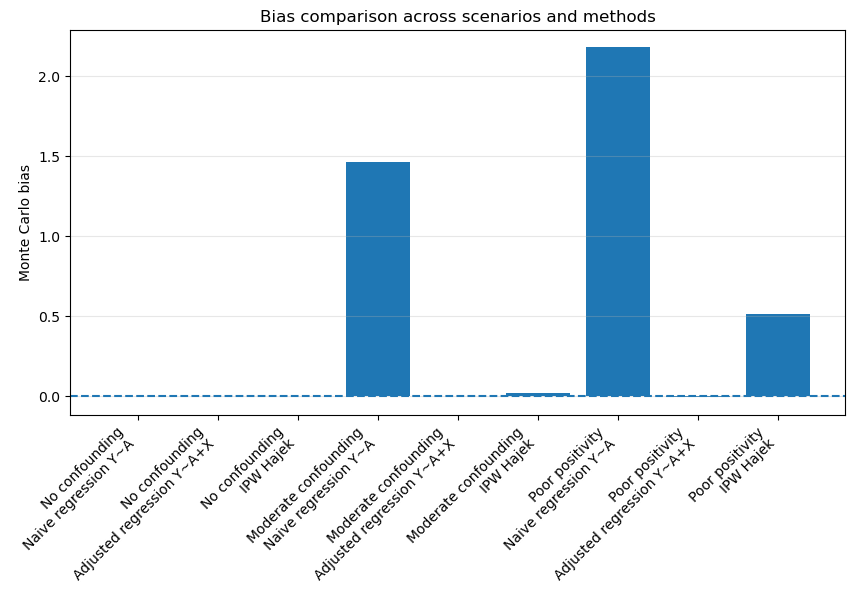

In [15]:
plt.figure(figsize=(10, 5))
x_labels, bias_values = [], []
for scenario_name in scenarios.keys():
    for method in ["Naive regression Y~A", "Adjusted regression Y~A+X", "IPW Hajek"]:
        value = summary.loc[(summary["Scenario"] == scenario_name) & (summary["Method"] == method), "Bias"].iloc[0]
        x_labels.append(f"{scenario_name}\n{method}")
        bias_values.append(value)

plt.bar(range(len(bias_values)), bias_values)
plt.axhline(0, linestyle="--")
plt.ylabel("Monte Carlo bias")
plt.title("Bias comparison across scenarios and methods")
plt.xticks(range(len(x_labels)), x_labels, rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.savefig(FIG_DIR / "04_bias_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Interpretation

In the no-confounding scenario, naive regression is approximately unbiased because treatment assignment is independent of the confounder.

In the moderate-confounding scenario, naive regression is biased because it ignores `X`. Adjusted regression and IPW perform better.

In the poor-positivity scenario, IPW can become unstable because a small number of observations receive large weights. This illustrates why causal inference requires both correct adjustment and sufficient overlap.

## Key message

A causal estimator is not only about fitting a model. It also depends on assumptions such as confounding control and positivity.